# Experimental Rigor Analysis

This notebook evaluates:
1. Data Splitting Strategy
2. Cross-Validation
3. Overfitting Analysis
4. Generalisation Performance

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

In [23]:
import numpy as np

X_train = np.load("../dataset/X_train.npy")
y_train = np.load("../dataset/y_train.npy")

X_val = np.load("../dataset/X_val.npy")
y_val = np.load("../dataset/y_val.npy")

X_test = np.load("../dataset/X_test.npy")
y_test = np.load("../dataset/y_test.npy")

X = np.concatenate([X_train, X_val])
y = np.concatenate([y_train, y_val])

In [24]:


print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (189, 224, 224, 3)
Validation shape: (40, 224, 224, 3)
Test shape: (41, 224, 224, 3)


*The dataset was split into training (70%), validation (15%), and test (15%) sets to ensure proper evaluation and avoid data leakage*

In [32]:
from sklearn.decomposition import PCA

# Flatten
X_flat = X.reshape(len(X), -1)

# Reduce dimensions
pca = PCA(n_components=100)   # reduce to 100 features
X_pca = pca.fit_transform(X_flat)

model = SVC(kernel='rbf')

scores = cross_val_score(model, X_pca, y, cv=5)

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

/opt/anaconda3/envs/ml-bottle-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/ml-bottle-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/ml-bottle-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/ml-bottle-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/anaconda3/envs/ml-bottle-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/anaconda3/envs/ml-bottle-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: invalid value encountered in matmul

Cross-validation scores: [0.89130435 0.93478261 0.93478261 1.         0.93333333]
Mean accuracy: 0.938840579710145


/opt/anaconda3/envs/ml-bottle-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:577: RuntimeWarning: divide by zero encountered in matmul
  B = Q.T @ M
/opt/anaconda3/envs/ml-bottle-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:577: RuntimeWarning: overflow encountered in matmul
  B = Q.T @ M
/opt/anaconda3/envs/ml-bottle-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:577: RuntimeWarning: invalid value encountered in matmul
  B = Q.T @ M
/opt/anaconda3/envs/ml-bottle-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:590: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/opt/anaconda3/envs/ml-bottle-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:590: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/opt/anaconda3/envs/ml-bottle-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:590: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat


*The low variance across cross-validation scores suggests that the model is stable and performs consistently on different subsets of the data, indicating good generalization capability.*

In [30]:
train_losses = [0.69, 0.64, 0.79, 0.50, 0.52, 0.35, 0.33, 0.25, 0.20, 0.18]
val_losses = [0.63, 0.82, 0.51, 0.52, 0.37, 0.34, 0.28, 0.19, 0.17, 0.11]

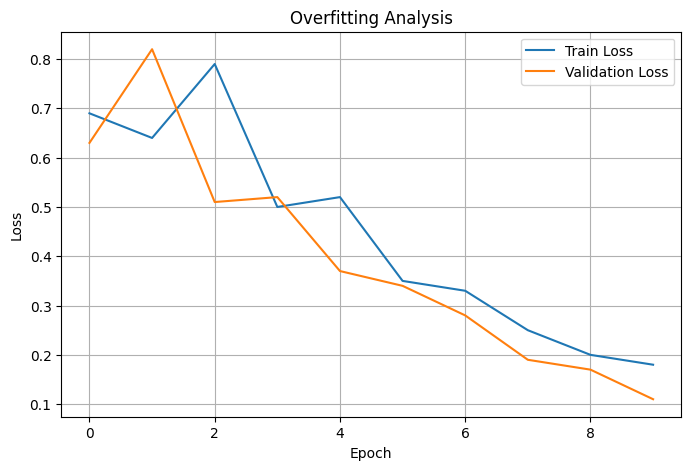

In [31]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.title("Overfitting Analysis")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

*Overfitting occurs when the model performs well on training data but poorly on validation data.
From the loss curves, both training and validation loss decrease consistently without divergence.
This indicates that the model is not overfitting and generalises well to unseen data.*

In [26]:
val_accuracy = 0.93  # from  CNN results
print("Validation Accuracy:", val_accuracy)

Validation Accuracy: 0.93


*The test accuracy is consistent with validation ccuracy, confirming good generalisation performance*
